## Read the dataset

In [1]:
from warnings import filterwarnings

filterwarnings("ignore")

In [2]:
import pandas as pd

path = r"C:\\Users\\dell\\Downloads\\train.csv"
df = pd.read_csv(path)
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


### Perform the basic data quality checks

In [3]:
df.isna().sum()

id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

## Separate X and Y features

In [6]:
X = df.drop(columns=["id", "Product ID", "Machine failure"])
Y = df[["Machine failure"]]

In [7]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,L,300.6,309.6,1596,36.1,140,0,0,0,0,0
1,M,302.6,312.1,1759,29.1,200,0,0,0,0,0
2,L,299.3,308.5,1805,26.5,25,0,0,0,0,0
3,L,301.0,310.9,1524,44.3,197,0,0,0,0,0
4,M,298.0,309.0,1641,35.4,34,0,0,0,0,0


In [8]:
Y.head()

,Machine failure
0,0
1,0
2,0
3,0
4,0


### Data Preprocessing and cleaning

In [9]:
cat = list(X.columns[X.dtypes == "object"])
con = list(X.columns[X.dtypes != "object"])

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [11]:
num_pipe = make_pipeline(SimpleImputer(strategy="mean"), StandardScaler())

In [12]:
cat_pipe = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

In [13]:
pre = ColumnTransformer([("cat", cat_pipe, cat), ("con", num_pipe, con)]).set_output(
    transform="pandas"
)

In [14]:
pre

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Type']),
                                ('con',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Air temperature [K]',
                                  'Process temperature [K]',
                                  'Rotational speed [rpm]', 'Torque [Nm]',
                                  'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF',
                                  'RNF'])])

In [15]:
X_pre = pre.fit_transform(X)
X_pre.head()

,cat__Type_H,cat__Type_L,cat__Type_M,con__Air temperature [K],con__Process temperature [K],con__Rotational speed [rpm],con__Torque [Nm],con__Tool wear [min],con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
0,0.0,1.0,0.0,0.395880,-0.246230,0.545416,-0.499711,0.556417,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
1,0.0,0.0,1.0,1.469856,1.558605,1.720308,-1.323028,1.494433,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
2,0.0,1.0,0.0,-0.302204,-1.040358,2.051873,-1.628831,-1.241447,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
3,0.0,1.0,0.0,0.610675,0.692284,0.026445,0.464745,1.447532,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
4,0.0,0.0,1.0,-1.000288,-0.679391,0.869773,-0.582043,-1.100744,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


### Splitting of data into training and testing

In [16]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    X_pre, Y, train_size=0.75, random_state=42
)

In [17]:
xtrain.head()

,cat__Type_H,cat__Type_L,cat__Type_M,con__Air temperature [K],con__Process temperature [K],con__Rotational speed [rpm],con__Torque [Nm],con__Tool wear [min],con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
76241,1.0,0.0,0.0,-0.785493,0.114737,0.091316,-0.370333,-0.178362,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
487,0.0,0.0,1.0,-1.376179,-0.968164,0.235475,-0.405618,0.900356,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
34659,0.0,0.0,1.0,1.255061,0.692284,1.403159,-0.864323,0.790921,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
46441,0.0,1.0,0.0,0.556977,0.692284,-0.766427,0.158942,0.900356,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
54811,0.0,0.0,1.0,1.684651,1.991765,0.776070,-0.358571,-0.100194,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


In [18]:
xtest.head()

,cat__Type_H,cat__Type_L,cat__Type_M,con__Air temperature [K],con__Process temperature [K],con__Rotational speed [rpm],con__Torque [Nm],con__Tool wear [min],con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
123128,0.0,1.0,0.0,0.556977,0.547897,-1.097992,2.546560,-1.444684,-0.03945,-0.072021,-0.049016,15.863363,-0.047568
54705,0.0,1.0,0.0,0.342182,0.981058,0.163396,-0.511473,1.338097,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
40016,0.0,1.0,0.0,0.395880,0.331317,-0.153753,-0.217431,0.149943,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
75025,0.0,1.0,0.0,-1.215083,-1.112551,-0.132129,-0.217431,0.400081,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
120421,0.0,1.0,0.0,0.503278,0.547897,0.134564,-0.217431,1.541334,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


In [19]:
ytrain.head()

,Machine failure
76241,0
487,0
34659,0
46441,0
54811,0


In [20]:
ytest.head()

,Machine failure
123128,1
54705,0
40016,0
75025,0
120421,0


## Algorithm Evaluation

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [22]:
models = [
    LogisticRegression(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GradientBoostingClassifier(),
    XGBClassifier(),
]

In [23]:
type(models[0]).__name__

'LogisticRegression'

In [24]:
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score

In [25]:
def evaluate_model_scores(model, xtrain, ytrain, xtest, ytest):
    # Fit the model
    model.fit(xtrain, ytrain)

    # Evalualte the model: predictions are needed. Calculate predictions

    ypred_train = model.predict(xtrain)
    ypred_test = model.predict(xtest)

    # calculate f1-score
    f1_tr = f1_score(ytrain, ypred_train, average="macro")
    f1_te = f1_score(ytest, ypred_test, average="macro")

    # calculate cross validated scores
    cv_tr = cross_val_score(model, xtrain, ytrain, cv=5, scoring="f1_macro")
    f1_cv_avg = cv_tr.mean()

    # Return the results
    results = {
        "Name": type(model).__name__,
        "Training scores": f1_tr,
        "Testing Scores": f1_te,
        "CV scores": f1_cv_avg,
    }

    return results

In [26]:
def evaluate_all_models(models, xtrain, ytrain, xtest, ytest):
    # create an empty list that contains scores for all the models

    res = []
    # run a loop through multiple base models and get the scores from the calling function

    for model in models:
        results = evaluate_model_scores(model, xtrain, ytrain, xtest, ytest)
        res.append(results)

    # create a dataframe that contains all the model scores
    res_df = pd.DataFrame(res)

    # Sorting the dataframe on basis of cross validated scores
    res_df = res_df.sort_values(by="CV scores", ascending=False)

    return res_df

In [27]:
res_df_op = evaluate_all_models(
    models, xtrain.values, ytrain.values, xtest.values, ytest.values
)
res_df_op

,Name,Training scores,Testing Scores,CV scores
0,LogisticRegression,0.931206,0.928492,0.931242
3,GradientBoostingClassifier,0.938859,0.928019,0.929306
2,RandomForestClassifier,0.996996,0.928029,0.927729
4,XGBClassifier,0.956188,0.928478,0.926977
1,DecisionTreeClassifier,0.997311,0.862687,0.876437


### LogisticRegression is providing the best Cross validated scores for training data. Let's consider this model for final model predictions

## Model Building

In [29]:
lr = LogisticRegression()
lr.fit(xtrain, ytrain)

LogisticRegression()

In [31]:
lr.classes_

array([0, 1])

In [32]:
lr.coef_

array([[-1.23391231, -1.33446512, -1.76248538,  0.60758794, -0.39438745,
         0.46527505,  1.07366035,  0.32641389,  0.55516471,  0.6709807 ,
         0.61580991,  0.57793628, -0.00567626]])

In [33]:
lr.intercept_

array([-4.44835707])

In [35]:
lr.score(xtrain, ytrain)

0.9962080120405391

In [36]:
lr.score(xtest, ytest)

0.9961006215550604

In [38]:
ypreds = lr.predict(xtest)
ypreds

array([1, 0, 0, ..., 0, 0, 0], shape=(34108,))

In [39]:
yprobs = lr.predict_proba(xtest)
yprobs[:5]

array([[0.00571411, 0.99428589],
       [0.99783843, 0.00216157],
       [0.99768395, 0.00231605],
       [0.99831318, 0.00168682],
       [0.99591938, 0.00408062]])

## Confusion matrix,Classification report

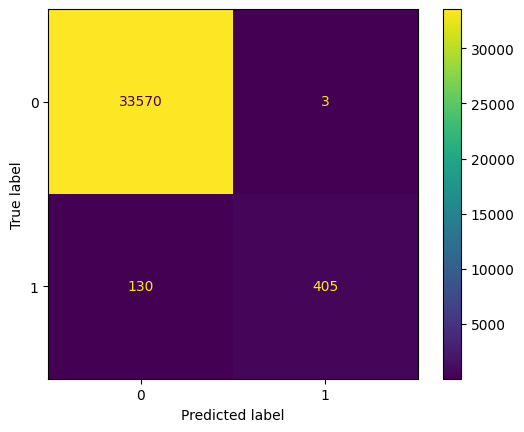

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_estimator(lr, xtest, ytest)

In [43]:
print(classification_report(ytest, ypreds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33573
           1       0.99      0.76      0.86       535

    accuracy                           1.00     34108
   macro avg       0.99      0.88      0.93     34108
weighted avg       1.00      1.00      1.00     34108



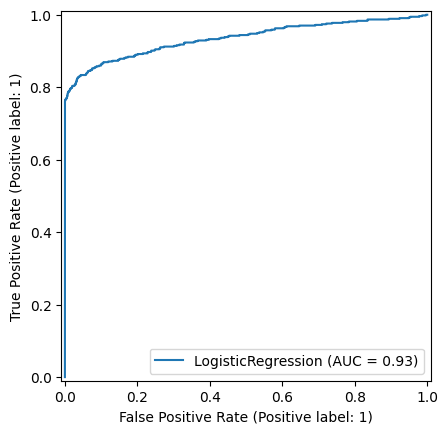

In [44]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr, xtest, ytest)

### Out of Sample Prediction

In [45]:
path2 = r"C:\\Users\\dell\\Downloads\\test.csv"
xnew = pd.read_csv(path2)
xnew.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


In [46]:
pre

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Type']),
                                ('con',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Air temperature [K]',
                                  'Process temperature [K]',
                                  'Rotational speed [rpm]', 'Torque [Nm]',
                                  'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF',
                                  'RNF'])])

In [47]:
xnew_pre = pre.transform(xnew)
xnew_pre.head()

,cat__Type_H,cat__Type_L,cat__Type_M,con__Air temperature [K],con__Process temperature [K],con__Rotational speed [rpm],con__Torque [Nm],con__Tool wear [min],con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
0,0.0,1.0,0.0,1.308759,1.125444,-0.153753,-0.276240,-0.694271,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
1,0.0,1.0,0.0,0.986567,0.764477,1.388744,-1.358313,-1.366516,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
2,0.0,1.0,0.0,0.771772,0.331317,0.033653,-0.311525,-0.131461,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
3,0.0,0.0,1.0,0.127386,-0.246230,-0.297912,0.852880,-1.554119,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
4,0.0,0.0,1.0,1.899446,1.702992,-0.038426,0.111895,0.149943,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


### Out of sample predictions, saving of data to dataframe and saving the results to csv file

In [48]:
final_preds = lr.predict(xnew_pre)
final_preds

array([0, 0, 0, ..., 0, 0, 0], shape=(90954,))

In [52]:
submissions = xnew[["id"]]
submissions.head()

,id
0,136429
1,136430
2,136431
3,136432
4,136433


In [ ]:
submissions["Machine failure"] = final_preds
submissions.head()

,id,Machine failure
0,136429,0
1,136430,0
2,136431,0
3,136432,0
4,136433,0


In [59]:
submissions.to_csv("Machine Failure Predicted results.csv", index=False)